In [1]:
import random
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import math

Given an arithmetic sequence $(U_n)$ of step $r$ and a first term $U_{min}$,  any element $U_n$ in the sequence can be computed as $U_n = U_{min} + n ⋅ r$. Therefore the indice of the element $U_n$ in the sequence is $n = \frac{U_n - U_{min}}{r}$. A function that implements this idea:

In [2]:
def normalize_angle(a):
  return ((a + 180) % 360) - 180

def get_idx(v, min_v=0.0, step=0.5):
  return round((v-min_v)/step)

**Kinematic Model of the Robot**
Here we will simply implement the simple kinematic model introduced in the blog post. Another robot model can be implemented since it will be modular

Given the previous pose or configuration $(x_{t-1}, y_{t-1}, θ_{t-1})$ of the robot, the next configuration can be computed as follow:
$x_t = x_{t-1} + v_t⋅cos(θ_{t-1}) $

$y_t = y_{t-1} + v_t⋅sin(θ_{t-1}) $

$x_t = x_{t-1} + Δθ_t $

with $v_t, Δθ_t$ being the velocity and orientation inputs at time step t. In our case, the robot can either rotate or move at a given time step, but not both at the same time. However, as I said, it is possible to change this kinematic and plug it to the value iteration allgorithm that we are going to implement

In [3]:
class Robot:
  def __init__(self, velocity=1.0, delta_theta=90.0) -> None:

     self.velocity = velocity
     self.delta_theta = delta_theta
     self.action_space = actions = ["stop", "move", "turn left", "turn right"]

     self.reset()

  def update(self, action):

    """ Update the kinematic of the robot given an action """
    if action=="move":
      #print(f"before: {self.x}-->{get_idx(self.x, -10.0, 0.5)}, {self.y}-->{get_idx(self.y, -10.0, 0.5)}, theta:{self.theta}")
      self.x = self.x + self.velocity*math.cos(math.radians(self.theta))
      self.y = self.y + self.velocity*math.sin(math.radians(self.theta))
      #print(f"after: {self.x}-->{get_idx(self.x, -10.0, 0.5)}, {self.y}-->{get_idx(self.y, -10.0, 0.5)},  theta:{self.theta}")

    elif action=="stop":
      pass

    elif action=="turn left":
      self.theta = normalize_angle(self.theta - self.delta_theta) #max(-180, self.theta - self.delta_theta)

    elif action=="turn right":
      self.theta = normalize_angle(self.theta + self.delta_theta) #min(self.theta + self.delta_theta, 180)

    else:
      raise f"action <{action}> does not exist in action space: {self.action_space}"


  def get_random_action(self):

    return random.choice(self.action_space)

  def reset(self, pose:np.ndarray|None=None):
    """ Reset the robot pose x, y, theta"""
    if pose is not None:
      self.x = pose[0].item()
      self.y = pose[1].item()
      self.theta = pose[2].item()
    else:
      self.x = 0.0
      self.y = 0.0
      self.theta = 0.0

  def print_pose(self):

    """ Simple print of the robot current pose"""
    print(f"X: {self.x} \tY: {self.y} \tTheta: {self.theta}")

# Quick test to validate this class

In [4]:
rb = Robot(delta_theta=45, velocity=1.0)
for i in range(10):
  action = rb.get_random_action()
  print(f"I have taken action: {action}")
  rb.update(action)

  rb.print_pose()

I have taken action: move
X: 1.0 	Y: 0.0 	Theta: 0.0
I have taken action: turn left
X: 1.0 	Y: 0.0 	Theta: -45.0
I have taken action: stop
X: 1.0 	Y: 0.0 	Theta: -45.0
I have taken action: turn left
X: 1.0 	Y: 0.0 	Theta: -90.0
I have taken action: turn left
X: 1.0 	Y: 0.0 	Theta: -135.0
I have taken action: stop
X: 1.0 	Y: 0.0 	Theta: -135.0
I have taken action: stop
X: 1.0 	Y: 0.0 	Theta: -135.0
I have taken action: stop
X: 1.0 	Y: 0.0 	Theta: -135.0
I have taken action: stop
X: 1.0 	Y: 0.0 	Theta: -135.0
I have taken action: move
X: 0.29289321881345254 	Y: -0.7071067811865476 	Theta: -135.0


In [5]:
class GridEnv:
  def __init__(self, X_limit, Y_limit, position_step, heading_step, rb:Robot, goal_position:np.ndarray | list) -> None:

    self.X_limit = X_limit
    self.Y_limit = Y_limit

    self.x_space = np.arange(X_limit[0], X_limit[1]+0.5, position_step)
    self.y_space = np.arange(Y_limit[0], Y_limit[1]+0.5, position_step)
    self.heading_space = np.arange(-180.0, 181.0, heading_step)


    # Create full grid
    X, Y, H = np.meshgrid(
        self.x_space,
        self.y_space,
        self.heading_space,
        indexing='ij'
    )

    # Flatten into giant list of tuples
    self.state_space = np.vstack([X.ravel(), Y.ravel(), H.ravel()]).T
    self.position_step = position_step
    self.heading_step = heading_step

    #discretizing the goal position
    goal_pos_x = self.x_space[get_idx(goal_position[0], X_limit[0], position_step)]
    goal_pos_y = self.y_space[get_idx(goal_position[1], Y_limit[0], position_step)]

    self.goal_position = np.array([goal_pos_x, goal_pos_y]) # discretized goal position which is the real pos in the grid world;

    self.rb = rb # Robot

    self.action_space = rb.action_space

    self.state = self.reset()

  def reset(self, pose:np.ndarray | None = None):

    self.rb.reset(pose)

    init_state = self.get_current_state()

    return init_state

  def reward_model(self, state, action , next_state):
    """ Return the reward of a transition. returns 0 if distance = 0, -1 otherwise """

    goal_reached = np.array_equal(next_state[:2], self.goal_position)

    return -float(not goal_reached)

  def step(self, action):

    # update the robot pose
    #print(f"before step:")
    #self.rb.print_pose()

    self.rb.update(action)
    #print(f"action: {action}")

    #print(f"x: {self.rb.x}, y: {self.rb.y}")

    self.rb.x = min(max(self.rb.x, self.X_limit[0]), self.X_limit[1])
    self.rb.y = min(max(self.rb.y, self.Y_limit[0]), self.Y_limit[1])

    next_state = self.get_current_state() # get the state after update
    #print(f"next state: {next_state}")
    reward = self.reward_model(self.state, action, next_state)
    done = (np.array_equal(next_state[:2], self.goal_position))

    self.state = next_state.copy()

    return next_state, reward, done

  def get_current_state(self):

    idx_x = get_idx(self.rb.x, self.X_limit[0], self.position_step)
    idx_y = get_idx(self.rb.y, self.Y_limit[0], self.position_step)
    #print(f"x ind: {idx_x}, y_idx: {idx_y}")
    idx_heading = get_idx(self.rb.theta, -180.0, self.heading_step)

    #print(f"idx heading: {idx_heading}")
    pos_x = self.x_space[min(idx_x, len(self.x_space)-1)]
    pos_y = self.y_space[min(idx_y, len(self.y_space)-1)]
    heading = self.heading_space[min(idx_heading, len(self.heading_space)-1)]

    state = np.array([pos_x, pos_y, heading])

    return state

  def state_to_idx(self, state):

    x_idx = get_idx(state[0], self.X_limit[0], self.position_step)
    y_idx = get_idx(state[1], self.Y_limit[0], self.position_step)
    heading_idx = get_idx(state[2], -180.0, self.heading_step)

    N_D = len(self.x_space)
    N_B = len(self.y_space)
    N_H = len(self.heading_space)

    flat_idx = x_idx * (N_B * N_H) + y_idx * N_H + heading_idx

    return flat_idx

  def idx_to_state(self, flat_idx):

    N_D = len(self.x_space)
    N_B = len(self.y_space)
    N_H = len(self.heading_space)

    # Recover the 3 indices
    x_idx = flat_idx // (N_B * N_H)
    rem = flat_idx % (N_B * N_H)

    y_idx = rem // N_H
    heading_idx = rem % N_H

    # Convert indices back to actual state values
    x = self.x_space[x_idx]
    y = self.y_space[y_idx]
    heading = self.heading_space[heading_idx]

    return (x, y, heading)

In [6]:

env = GridEnv([-10.0, 10.0], [-10.0, 10.0], 0.5, 45, rb, np.array([5.0, 5.0]))
state = env.reset()
print(state)
for i in range(15):
  action = env.rb.get_random_action()
  print(f"\nstate: {env.state} ", end=" ")
  next_state, reward, done = env.step(action)
  print(f"action: {action} next state: {next_state} reward: {reward}")
  env.rb.print_pose()

  state = next_state


[0. 0. 0.]

state: [0. 0. 0.]  action: turn left next state: [  0.   0. -45.] reward: -1.0
X: 0.0 	Y: 0.0 	Theta: -45.0

state: [  0.   0. -45.]  action: turn right next state: [0. 0. 0.] reward: -1.0
X: 0.0 	Y: 0.0 	Theta: 0.0

state: [0. 0. 0.]  action: turn left next state: [  0.   0. -45.] reward: -1.0
X: 0.0 	Y: 0.0 	Theta: -45.0

state: [  0.   0. -45.]  action: turn right next state: [0. 0. 0.] reward: -1.0
X: 0.0 	Y: 0.0 	Theta: 0.0

state: [0. 0. 0.]  action: turn left next state: [  0.   0. -45.] reward: -1.0
X: 0.0 	Y: 0.0 	Theta: -45.0

state: [  0.   0. -45.]  action: turn left next state: [  0.   0. -90.] reward: -1.0
X: 0.0 	Y: 0.0 	Theta: -90.0

state: [  0.   0. -90.]  action: stop next state: [  0.   0. -90.] reward: -1.0
X: 0.0 	Y: 0.0 	Theta: -90.0

state: [  0.   0. -90.]  action: move next state: [  0.  -1. -90.] reward: -1.0
X: 6.123233995736766e-17 	Y: -1.0 	Theta: -90.0

state: [  0.  -1. -90.]  action: turn right next state: [  0.  -1. -45.] reward: -1.0
X: 6.

In [7]:
env.state_space.shape

(15129, 3)

In [8]:
env.state_space[:20]

array([[ -10. ,  -10. , -180. ],
       [ -10. ,  -10. , -135. ],
       [ -10. ,  -10. ,  -90. ],
       [ -10. ,  -10. ,  -45. ],
       [ -10. ,  -10. ,    0. ],
       [ -10. ,  -10. ,   45. ],
       [ -10. ,  -10. ,   90. ],
       [ -10. ,  -10. ,  135. ],
       [ -10. ,  -10. ,  180. ],
       [ -10. ,   -9.5, -180. ],
       [ -10. ,   -9.5, -135. ],
       [ -10. ,   -9.5,  -90. ],
       [ -10. ,   -9.5,  -45. ],
       [ -10. ,   -9.5,    0. ],
       [ -10. ,   -9.5,   45. ],
       [ -10. ,   -9.5,   90. ],
       [ -10. ,   -9.5,  135. ],
       [ -10. ,   -9.5,  180. ],
       [ -10. ,   -9. , -180. ],
       [ -10. ,   -9. , -135. ]])

Here we are going to implment the class for value iteration according to the official algorithm from *Sutton & Barto* that I showed in the blog. And finally, we will derive the optimal policy from the optimal value function. Note that, the only purpose of value iteration is to obtain the optimal value function. The optimal policy can be obtained in various ways, but we will simply use the action value function.

In [9]:
from tqdm import tqdm

In [41]:
class ValueIteration:
    def __init__(self, env:GridEnv) -> None:
        self.env = env
        self.value_array = np.zeros(env.state_space.shape[0])
        self.prev_value_array = self.value_array.copy()
        self.gamma = 0.99

        self.trans_matrix = self.create_transition_matrix()


    def create_transition_matrix(self):

        transition = {} # {state: {action1: next_state_1, action2: next_state2, ...}, ...}
        for state in self.env.state_space:
            transition[self.state_to_str(state)] = {}
            for action in self.env.action_space:
                next_state = self.get_next_state(state, action)
                reward = self.env.reward_model(state, action, next_state)
                transition[self.state_to_str(state)][action] = (next_state, reward)

        return transition

    def transition_prob(self, state, action, reward, next_state):

        return 1.0

    def get_next_state(self, state, action):

        self.env.rb.reset(state)


        # Get the actual outcome of taking 'action' from 'state_array'
        observed_next_state, observed_reward_from_step, done = self.env.step(action)

        return observed_next_state

    def get_state_next_states(self, state):

        state_dict = {self.state_to_str(state):[]}

        for action in self.env.action_space:
            next_state = self.get_next_state(state, action)
            state_dict[self.state_to_str(state)].append(next_state)

        return state_dict

    def state_to_str(self, state):

        return f"({state[0]}, {state[1]}, {state[2]})"

    def run(self, num_iterations:int=20):

        iterator = tqdm(iterable=range(num_iterations), desc="Iteration: ", total=num_iterations)
        state_iterator = tqdm(iterable=range(self.env.state_space.shape[0]-1), desc="Iteration state: ", total=self.env.state_space.shape[0])
        next_state_iterator = tqdm(iterable=range(self.env.state_space.shape[0]), desc="Iteration next state: ", total=self.env.state_space.shape[0])
        delta_v = 1
        epsilon = 1e-6
        iter = 0
        while delta_v>epsilon:


            for state_idx in range(self.env.state_space.shape[0]):
                state_array = self.env.state_space[state_idx]

                max_value_for_state = -np.inf # Initialize value for the current state to a very low number (for maximization)

                for action in self.env.action_space:

                    next_state_array, reward = self.trans_matrix[self.state_to_str(state_array)][action] #[0]
                    # Calculate the reward for transitioning to this candidate_next_state_array
                    #reward = self.env.reward_model(state_array, action, next_state_array)

                    next_state_value = self.value_array[self.env.state_to_idx(next_state_array)]

                    # Pass both the observed next state and observed reward for comparison.
                    prob = self.transition_prob(state_array, action, reward, next_state_array)

                    q_value_for_action = prob * (reward + self.gamma * next_state_value)

                    # Update the maximum value for the current state (taking max over actions)
                    if q_value_for_action > max_value_for_state:
                        max_value_for_state = q_value_for_action

                    self.value_array[state_idx] = round(max_value_for_state, 3)

            norm_v = self.get_value_norm(self.value_array)
            norm_prev_v = self.get_value_norm(self.prev_value_array)
            delta_v = abs(norm_v-norm_prev_v)

            self.prev_value_array = self.value_array.copy()
            iter += 1
            print(f"=============================================")
            print(f"[ITERATION N°{iter}] delta_v: {delta_v}")




        return self.value_array



    def extract_action_value(self):

        self.action_qvalues_array = np.zeros((self.value_array.shape[0], len(self.env.action_space)))

        for state_idx in range(self.env.state_space.shape[0]):
            state_array = self.env.state_space[state_idx]
            transitions = self.trans_matrix[self.state_to_str(state_array)]

            max_value_for_action_state = -np.inf

            for action, next_state_rew in transitions.items():

                next_state_array, reward = next_state_rew

                next_state_value = self.value_array[self.env.state_to_idx(next_state_array)]

                # Pass both the observed next state and observed reward for comparison.
                prob = self.transition_prob(state_array, action, reward, next_state_array)

                q_value_for_action = reward + prob * (self.gamma * next_state_value)

                action_idx = self.env.action_space.index(action)

                #print(q_value_for_action)
                self.action_qvalues_array[state_idx, action_idx] =  q_value_for_action

    def policy(self, state):

        best_action_idx = np.argmax(self.action_qvalues_array[self.env.state_to_idx(state)])

        return self.env.action_space[best_action_idx]

    def get_value_norm(self, v:np.ndarray):

        return np.linalg.norm(v)



One thing in dynamic programming thus value iteration is to loop over all states. Even though we follow this strategy here, other strategies exist. We can randomly shuffle inital states for the robot and then from them, we do value iteration. Or a more deterministic strategy, like row by row. For instance $(x=0, y=1, θ=0.0), (x=0, y=2, θ=0.0), ..., (x=10, y=10, θ=0.0)$. You can still use a more sophisticated techniques to choose the state, such as multi-armed bandit where bandits are states (huge action space indeed !) but it may be worth it. I haven't tried those strategy myself, but they can be interesting to explore.

In [42]:
angle_step = 45 # degree
rb1 = Robot(1.1, angle_step)
env1 = GridEnv([-10.0, 10.0], [-10.0, 10.0], 1., angle_step, rb1, np.array([0.0, 0.0]))
valiter = ValueIteration(env1)
test_state = valiter.env.state_space[0]
valiter.get_state_next_states(test_state)
valiter.run(200)
"""keys = list(valiter.trans_matrix.keys())[-100:]
values = list(valiter.trans_matrix.values())[-100:]
for i in range(len(keys)):
  print(f"{keys[i]}: {values[i]}")"""

Iteration state:   0%|          | 0/3969 [00:00<?, ?it/s]

Iteration next state:   0%|          | 0/3969 [00:00<?, ?it/s]

[ITERATION N°1] delta_v: 62.85698051927089
[ITERATION N°2] delta_v: 61.90852913784563
[ITERATION N°3] delta_v: 60.528800023456114
[ITERATION N°4] delta_v: 58.48610380664735
[ITERATION N°5] delta_v: 55.734778721790036
[ITERATION N°6] delta_v: 52.02172406010749
[ITERATION N°7] delta_v: 47.37692299946502
[ITERATION N°8] delta_v: 41.772015453349695
[ITERATION N°9] delta_v: 35.026771921507475
[ITERATION N°10] delta_v: 26.946804888488032
[ITERATION N°11] delta_v: 17.36731314569039
[ITERATION N°12] delta_v: 9.381923876269866


Iteration next state:   0%|          | 0/3969 [00:02<?, ?it/s]

[ITERATION N°13] delta_v: 3.367355670176039
[ITERATION N°14] delta_v: 0.0


'keys = list(valiter.trans_matrix.keys())[-100:]\nvalues = list(valiter.trans_matrix.values())[-100:]\nfor i in range(len(keys)):\n  print(f"{keys[i]}: {values[i]}")'

In [43]:
valiter.env.rb.reset(np.array([-5.0 ,  6.,  -45.]))
print(valiter.env.step("move"))
valiter.trans_matrix[valiter.state_to_str(np.array([-8. ,  6.,  -45.]))]

(array([ -4.,   5., -45.]), -1.0, False)


{'stop': (array([ -8.,   6., -45.]), -1.0),
 'move': (array([ -7.,   5., -45.]), -1.0),
 'turn left': (array([ -8.,   6., -90.]), -1.0),
 'turn right': (array([-8.,  6.,  0.]), -1.0)}

In [44]:
valiter.env.x_space, valiter.env.y_space

(array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]),
 array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]))

In [45]:
value_array = valiter.value_array.reshape(env1.x_space.shape[0], env1.y_space.shape[0], env1.heading_space.shape[0])
value_array[:10]

array([[[-11.361, -12.247, -11.361, ...,  -9.562, -10.466, -11.361],
        [-12.247, -12.247, -11.361, ..., -10.466, -11.361, -12.247],
        [-12.247, -12.247, -11.361, ..., -10.466, -11.361, -12.247],
        ...,
        [-12.247, -11.361, -10.466, ..., -11.361, -12.247, -12.247],
        [-12.247, -11.361, -10.466, ..., -11.361, -12.247, -12.247],
        [-11.361, -10.466,  -9.562, ..., -11.361, -12.247, -11.361]],

       [[-11.361, -12.247, -12.247, ...,  -9.562, -10.466, -11.361],
        [-10.466, -11.361, -10.466, ...,  -8.648,  -9.562, -10.466],
        [-11.361, -11.361, -10.466, ...,  -9.562, -10.466, -11.361],
        ...,
        [-11.361, -10.466,  -9.562, ..., -10.466, -11.361, -11.361],
        [-10.466,  -9.562,  -8.648, ..., -10.466, -11.361, -10.466],
        [-11.361, -10.466,  -9.562, ..., -12.247, -12.247, -11.361]],

       [[-11.361, -12.247, -12.247, ...,  -9.562, -10.466, -11.361],
        [-10.466, -11.361, -11.361, ...,  -8.648,  -9.562, -10.466],
    

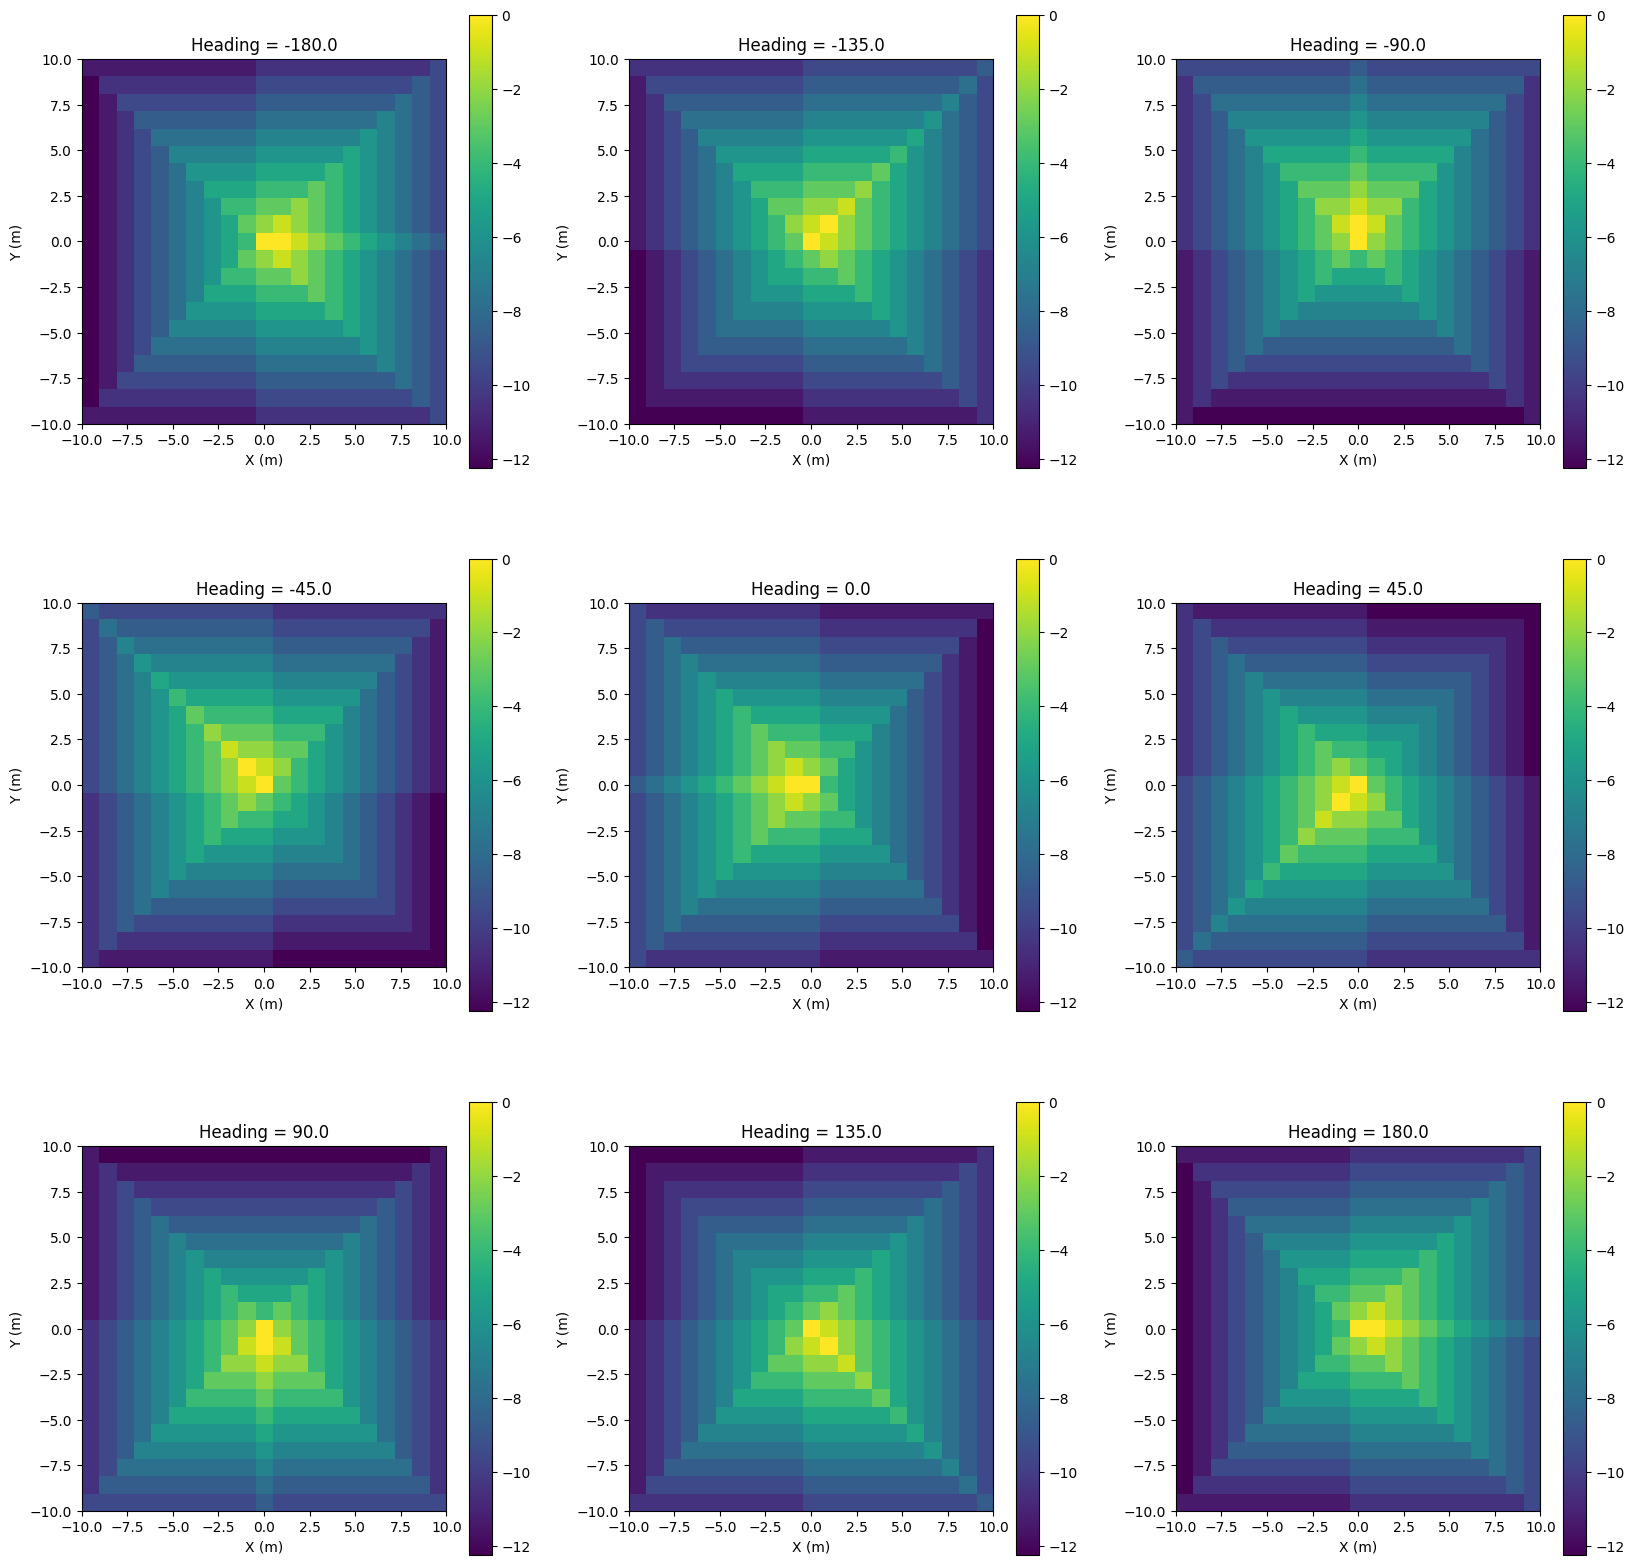

In [46]:
# V is your value table shaped (N_D, N_B, N_H)
plt.figure(figsize=(20, 20))
for h in range(env1.heading_space.shape[0]):
    plt.subplot(3, env1.heading_space.shape[0]//3, h + 1)
    plt.imshow(value_array[:, :, h].T, cmap='viridis', origin='lower', extent=[-10, 10, -10, 10])

    plt.title(f"Heading = {valiter.env.heading_space[h]}")
    plt.colorbar()
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")

plt.show()

The figure above is very beautiful ! In the figure, the yellow colors have higher value than the dark part. Without surprise, the closer is a state to the goal position $(x=0, y=0, θ)$, the higher its value. That's very interesting because even though the states have the same reward, their value is  different. Only following the reward will give no information, only the long term or cumultive reward, or simply called the value offers enough contrast between states suitable for decision making. We can see that the value function reflects faithfully the geometry of the environment. For instance, take the first one plot with $ϴ=-180°$ (the agent facing left side), the strongest yellow line $(x, y=0)$ is obviously the strongest values because the robot is already facing the goal, thus just need to move. No turn required, thus no exra penalty. The plot with $\theta = + 180°$ clearly is the symmetric of this one. Do all the other figures make sense to you ?

In [47]:
state = np.array([0.0, 10.0, .0])
valiter.value_array = value_array.reshape(-1).copy()
valiter.extract_action_value()
num_iter = 30
done = False
num_action = 0

for i in range(num_iter):
  num_action += 1
  action = valiter.policy(state)
  next_state, reward = valiter.trans_matrix[valiter.state_to_str(state)][action]
  value = valiter.action_qvalues_array[valiter.env.state_to_idx(state)]
  done = (np.array_equal(next_state[:2], valiter.env.goal_position))
  print(f"------------------------------- step n°: {num_action} -------------------------------")
  print(f"state: {state}, action: {action}, next_state: {next_state} done: {done} value: {value}")
  print(f"------------------------------- --------------------- -------------------------------")

  state = next_state.copy()
  if done:
    break

------------------------------- step n°: 1 -------------------------------
state: [ 0. 10.  0.], action: turn left, next_state: [  0.  10. -45.] done: False value: [-11.36134 -12.24739 -10.46638 -12.24739]
------------------------------- --------------------- -------------------------------
------------------------------- step n°: 2 -------------------------------
state: [  0.  10. -45.], action: turn left, next_state: [  0.  10. -90.] done: False value: [-10.46638 -10.46638  -9.56152 -11.36134]
------------------------------- --------------------- -------------------------------
------------------------------- step n°: 3 -------------------------------
state: [  0.  10. -90.], action: move, next_state: [  0.   9. -90.] done: False value: [ -9.56152  -8.64775 -10.46638 -10.46638]
------------------------------- --------------------- -------------------------------
------------------------------- step n°: 4 -------------------------------
state: [  0.   9. -90.], action: move, next_stat

In [48]:
state = np.array([-10.0, 10.0, 180.0])
valiter.value_array = value_array.reshape(-1).copy()
valiter.extract_action_value()
num_iter = 30
done = False
num_action = 0
for i in range(num_iter):
  num_action += 1
  action = valiter.policy(state)
  next_state, reward = valiter.trans_matrix[valiter.state_to_str(state)][action]
  done = (np.array_equal(next_state[:2], valiter.env.goal_position))
  print(f"------------------------------- step n°: {num_action} -------------------------------")
  print(f"state: {state}, action: {action}, next_state: {next_state} done: {done}")
  print(f"------------------------------- --------------------- -------------------------------")

  state = next_state.copy()

  if done:
    break

------------------------------- step n°: 1 -------------------------------
state: [-10.  10. 180.], action: turn right, next_state: [ -10.   10. -135.] done: False
------------------------------- --------------------- -------------------------------
------------------------------- step n°: 2 -------------------------------
state: [ -10.   10. -135.], action: turn right, next_state: [-10.  10. -90.] done: False
------------------------------- --------------------- -------------------------------
------------------------------- step n°: 3 -------------------------------
state: [-10.  10. -90.], action: turn right, next_state: [-10.  10. -45.] done: False
------------------------------- --------------------- -------------------------------
------------------------------- step n°: 4 -------------------------------
state: [-10.  10. -45.], action: move, next_state: [ -9.   9. -45.] done: False
------------------------------- --------------------- -------------------------------
------------

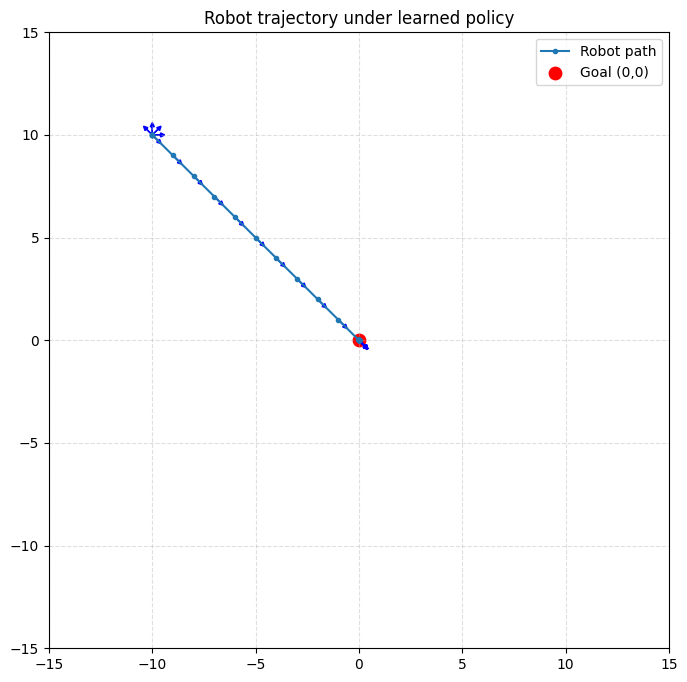

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# --- Run the policy rollout and store the path ---

valiter.value_array = value_array.reshape(-1).copy()
valiter.extract_action_value()

state = np.array([-10.0, 10.0, 135.0])
xs, ys, thetas = [], [], []
num_iter = 30
done = False
for i in range(num_iter):
    xs.append(state[0])
    ys.append(state[1])
    thetas.append(np.deg2rad(state[2]))

    action = valiter.policy(state)
    next_state, reward = valiter.trans_matrix[valiter.state_to_str(state)][action]

    state = next_state.copy()

    if done:
      break

# --- Plot the trajectory ---
plt.figure(figsize=(8,8))
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.grid(True, linestyle='--', alpha=0.4)

# Plot path
plt.plot(xs, ys, '-o', markersize=3, label='Robot path')

# Plot goal
plt.scatter([0], [0], color='red', s=80, label='Goal (0,0)')

# Plot orientation arrows
for x, y, th in zip(xs, ys, thetas):  # every 3 steps for clarity
    plt.arrow(x, y, 0.4*np.cos(th), 0.4*np.sin(th),
              head_width=0.2, head_length=0.2, fc='blue', ec='blue')

plt.title("Robot trajectory under learned policy")
plt.legend()
plt.show()


#**Trajectory Visualization using the optimal policy**
The figure below shows some trajectories from some interesting starting positions. The blue arrows indicates the current orientation of the robot. Each turn corresponds to 45° rotation. All trajectories are optimal !

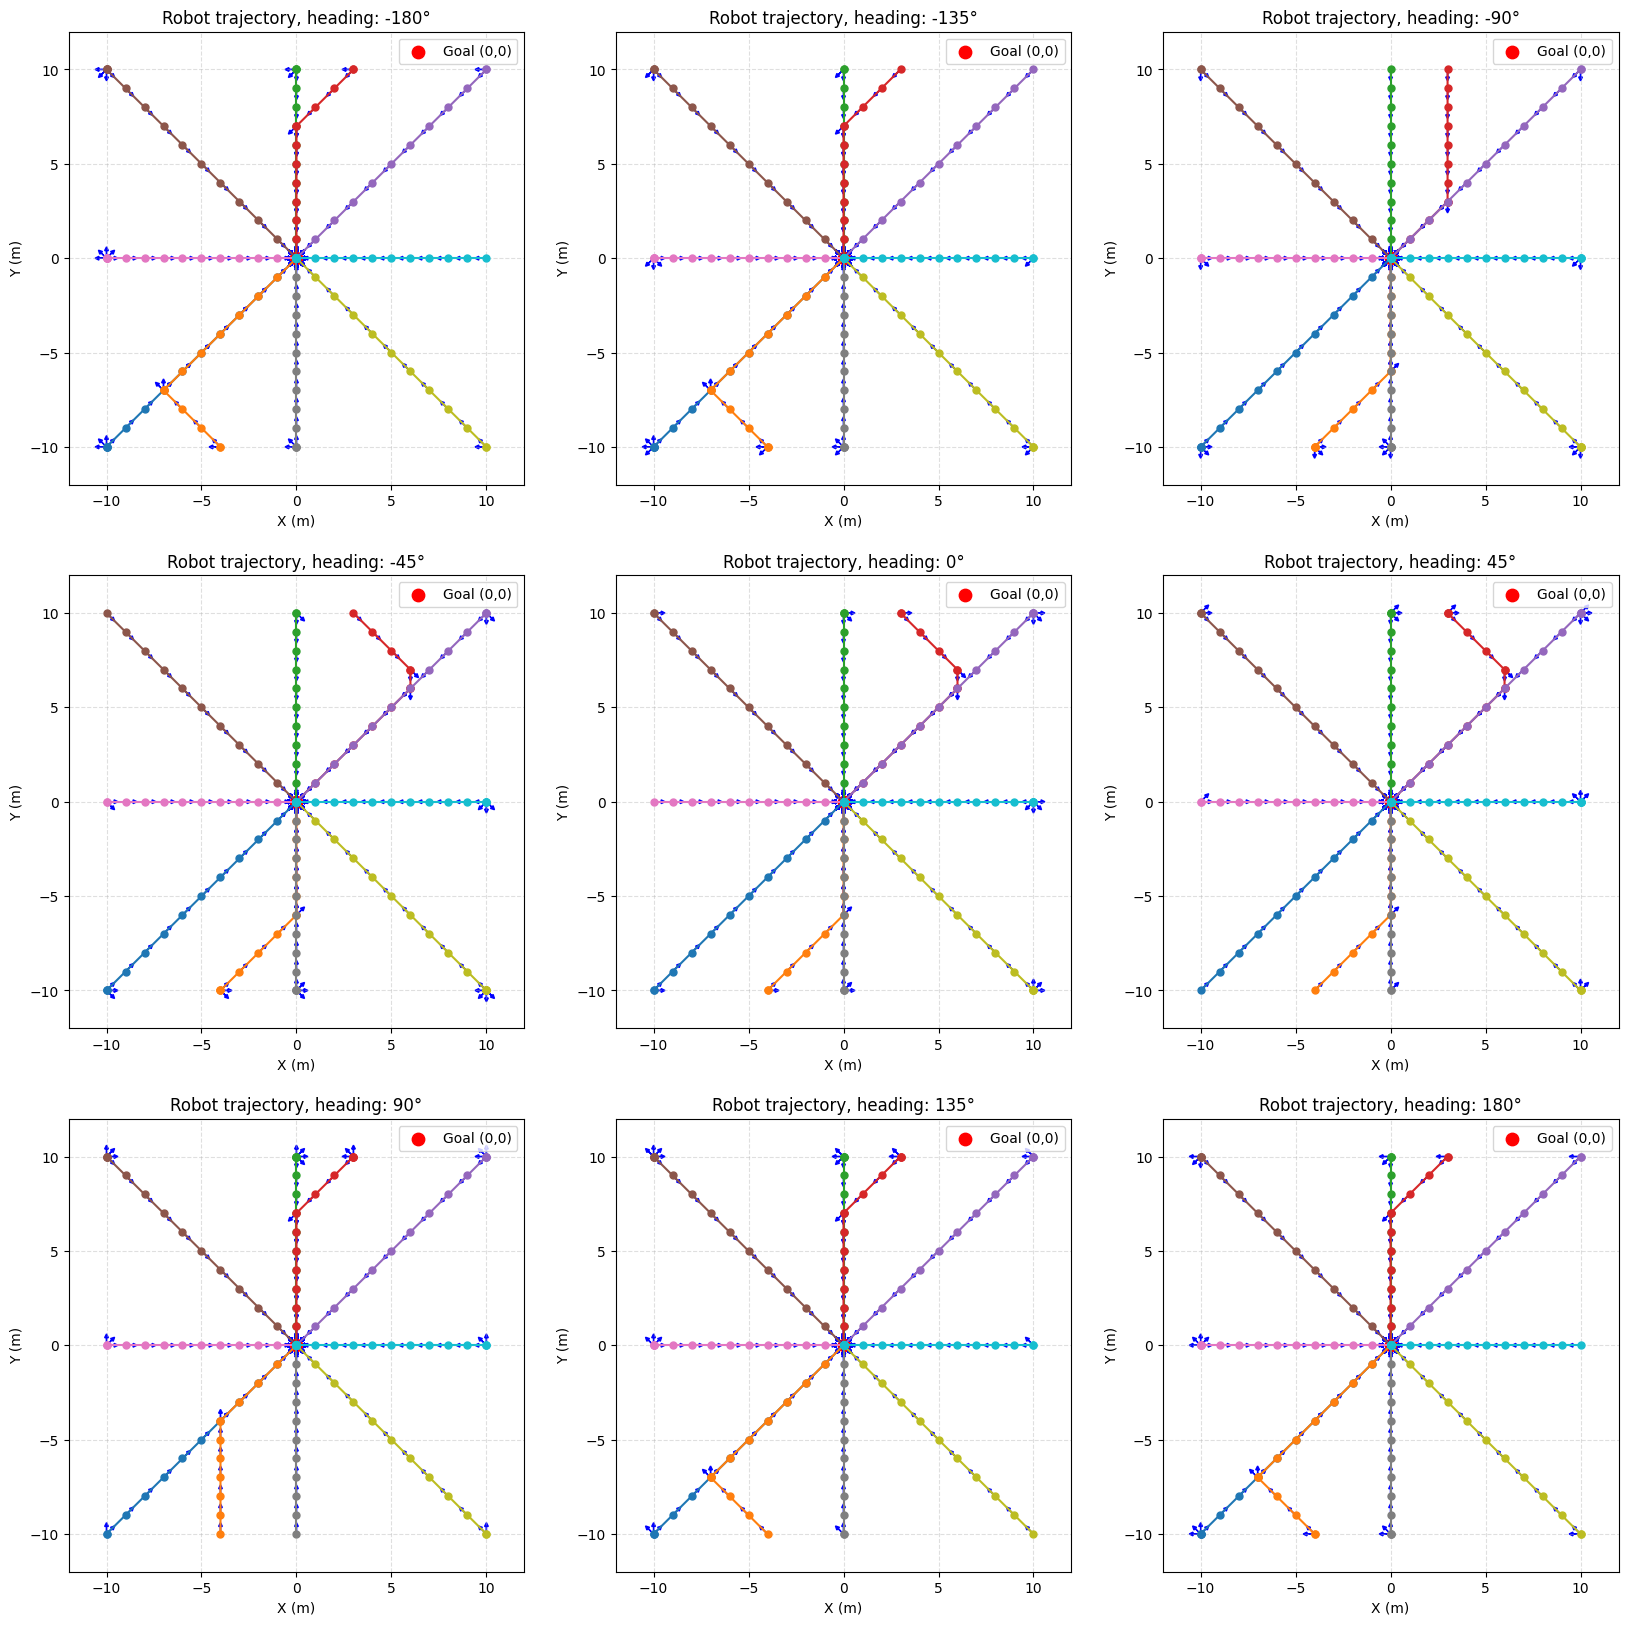

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# --- Run the policy rollout and store the path ---

valiter.value_array = value_array.reshape(-1).copy()
valiter.extract_action_value()

# --- Plot the trajectory ---
plt.figure(figsize=(20,20))

num_iter = 30

heading_list = [-180, -135, -90, -45, 0, 45, 90, 135, 180]
for j in range (len(heading_list)):

  heading = heading_list[j]
  state_list = [
      np.array([-10.0, -10.0, heading]), np.array([-4.0, -10.0, heading]), np.array([0.0, 10.0, heading]), np.array([3., 10.0, heading]), np.array([10.0, 10.0, heading]), np.array([-10.0, 10.0, heading]), np.array([-10.0, 0.0, heading]),
                np.array([0.0, -10.0, heading]), np.array([10.0, -10.0, heading]), np.array([10.0, 0.0, heading])
                ]
  plt.subplot(3, len(heading_list)//3, j+1)
  plt.xlim(-12, 12)
  plt.ylim(-12, 12)
  plt.grid(True, linestyle='--', alpha=0.4)

  # Plot goal
  plt.scatter(valiter.env.goal_position[0], valiter.env.goal_position[1], color='red', s=80, label='Goal (0,0)')

  for i in range(len(state_list)):
    xs, ys, thetas = [], [], []
    state = state_list[i]
    done = False
    for i in range(num_iter):
        xs.append(state[0])
        ys.append(state[1])
        thetas.append(np.deg2rad(state[2]))

        action = valiter.policy(state)
        next_state, reward = valiter.trans_matrix[valiter.state_to_str(state)][action]

        state = next_state.copy()

        if done:
          break

    # Plot path
    if i==0:
        plt.plot(xs, ys, '-o', markersize=5, label='Robot path')
    else:
        plt.plot(xs, ys, '-o', markersize=5)
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")

    # Plot orientation arrows
    for x, y, th in zip(xs, ys, thetas):  # every 3 steps for clarity
        plt.arrow(x, y, 0.4*np.cos(th), 0.4*np.sin(th),
                  head_width=0.2, head_length=0.2, fc='blue', ec='blue')



  plt.title(f"Robot trajectory, heading: {heading}°")
  plt.legend(loc="upper right")

plt.show()